In [3]:
import pandas as pd

df = pd.read_csv("01-jogja-jan-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,1/1/2021,00:00:00,13,40,0,25,0,0,40,PM2.5,Good
2,1/1/2021,01:00:00,12,38,0,24,0,0,38,PM2.5,Good
3,1/1/2021,02:00:00,11,35,0,23,0,0,35,PM2.5,Good
4,1/1/2021,03:00:00,10,32,0,22,0,0,32,PM2.5,Good
5,1/1/2021,04:00:00,9,29,0,21,0,0,29,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,1/31/2021,19:00:00,25,66,19,25,40,6,66,PM2.5,Moderate
741,1/31/2021,20:00:00,24,65,19,24,39,5,65,PM2.5,Moderate
742,1/31/2021,21:00:00,23,64,19,24,38,5,64,PM2.5,Moderate
743,1/31/2021,22:00:00,23,63,19,24,38,5,63,PM2.5,Moderate


#### <span style="color:blue">**Data Quality Check**</span>

In [4]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 02-jogja-feb-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                672 non-null    str    
 1   Time                672 non-null    str    
 2   PM10                672 non-null    int64  
 3   PM2.5               672 non-null    int64  
 4   SO2                 672 non-null    int64  
 5   CO                  672 non-null    int64  
 6   O3                  657 non-null    float64
 7   NO2                 672 non-null    int64  
 8   Max                 672 non-null    int64  
 9   Critical Component  672 non-null    str    
 10  Category            672 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 57.9 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [5]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 02-jogja-feb-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,672.000000,672.000000,672.000000,672.000000,657.000000,672.000000,672.000000
mean,18.760417,57.680060,20.964286,23.467262,34.925419,4.153274,58.943452
std,5.818725,11.901872,2.458945,5.749785,14.579750,1.379655,10.728450
min,7.000000,26.000000,16.000000,7.000000,9.000000,2.000000,27.000000
25%,15.000000,52.000000,19.000000,23.000000,24.000000,3.000000,53.000000
50%,19.000000,59.000000,20.000000,24.000000,35.000000,4.000000,60.000000
75%,24.000000,66.000000,22.000000,26.000000,41.000000,5.000000,67.000000
max,30.000000,80.000000,31.000000,38.000000,71.000000,8.000000,80.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [6]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 02-jogja-feb-2021.csv


Critical Component
PM2.5    87.053571
O3       12.946429
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [7]:
filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 02-jogja-feb-2021.csv


Category
Moderate    82.738095
Good        17.261905
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 02-jogja-feb-2021.csv


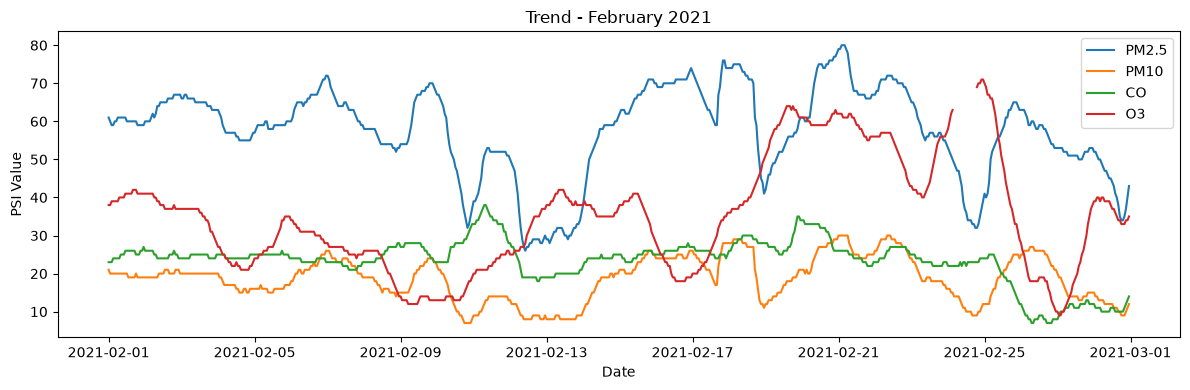

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the February data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - February 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In February 2021, PM2.5 stayed the highest most of the month (mostly 40–80), O3 also went up and down a lot and even crossed PM2.5 a few times, while PM10 and CO stayed lower and calmer overall.**

##### <span style="color:blue">**2. Boxplot**</span>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - February 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**In February 2021, PM2.5 had the highest middle value (median = 59), while PM10 was the lowest and had no outliers, CO and O3 had some unusual values, and CO's values were very close together.**

In [9]:
print(df[["O3"]].describe())
print(df["O3"].isna().sum())

               O3
count  657.000000
mean    34.925419
std     14.579750
min      9.000000
25%     24.000000
50%     35.000000
75%     41.000000
max     71.000000
15


##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 02-jogja-feb-2021.csv


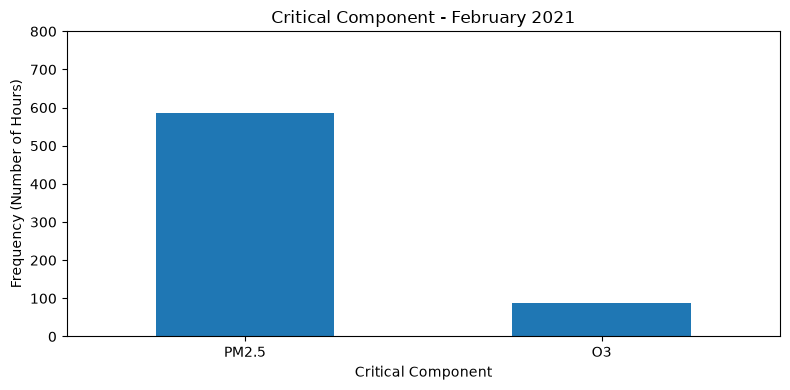

Critical Component
PM2.5    585
O3        87
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

# Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - February 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)  # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()  # Display the counts for each bar of Critical Component

**In February 2021, PM2.5 was again the main driver of poor air quality (585 hours), far ahead of O3, CO, and SO2, which each stayed under 100 hours, which is the same pattern as January**

Data source: 02-jogja-feb-2021.csv


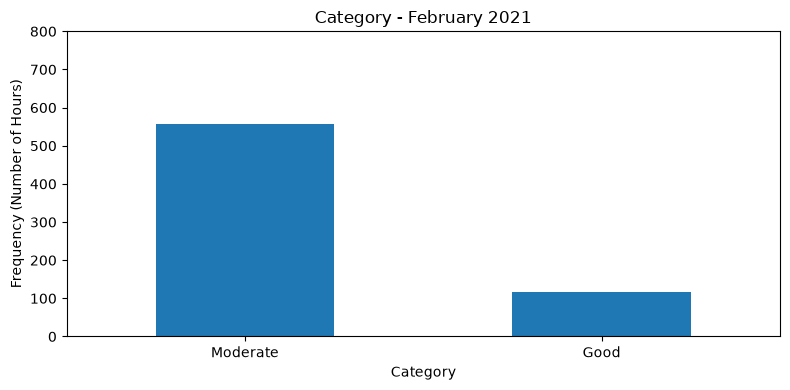

Category
Moderate    556
Good        116
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "02-jogja-feb-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - February 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category

**In February 2021, air quality showed significant differences between Moderate (556 hours) and Good (116 hours).**